In [24]:
import pandas as pd
import numpy as np
import re
# 读取数据
df = pd.read_csv('/data/raw/生产单已完成近3个月.csv', encoding='utf-8-sig')
print(df.columns.tolist())
print(f'共 {len(df)} 行')

['生产排程单', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']
共 328 行


In [25]:
df_raw = pd.read_csv('/data/raw/生产单已完成近3个月.csv',
                     encoding='utf-8-sig', header=None)
print(df_raw.head(5).to_string())

                0       1           2           3                    4         5                          6            7             8     9       10                                                                11  12
0            生产排程单     NaN         NaN         NaN                  NaN       NaN                        NaN          NaN           NaN   NaN     NaN                                                               NaN NaN
1              订单号    客户名称        订单日期        交货日期                   名称   印版号/模具号                       原料代码         纸箱规格          原料规格  排产数量     总平方                                                                备注 NaN
2  XS2025011500002      奉航  2025-01-15  2025-01-20  汉德车桥505*505*130 （外）  HY00328/  160.110B.110.130C.130--BC  505*505*130  2055*640\r\n   300  645.76                                                       碰线，印刷，开槽，打钉 NaN
3  XS2025071000001    中星测控  2025-07-10  2025-07-15         包装盒504000022     /P085      白牛皮170.120E.140白木桨--E   130*30*12

In [26]:
df = pd.read_csv('/data/raw/生产单已完成近3个月.csv',
                 encoding='utf-8-sig',
                 header=1)          # 用第1行（从0数）作为列名

print(df.columns.tolist())
print(f'共 {len(df)} 行')
df.head(3)

['订单号', '客户名称', '订单日期', '交货日期', '名称', '印版号/模具号', '原料代码', '纸箱规格', '原料规格', '排产数量', '总平方', '备注', 'Unnamed: 12']
共 327 行


,订单号,客户名称,订单日期,交货日期,名称,印版号/模具号,原料代码,纸箱规格,原料规格,排产数量,总平方,备注,Unnamed: 12
0,XS2025011500002,奉航,2025-01-15,2025-01-20,汉德车桥505*505*130 （外）,HY00328/,160.110B.110.130C.130--BC,505*505*130,2055*640\r\n,300,645.76,碰线，印刷，开槽，打钉,NaN
1,XS2025071000001,中星测控,2025-07-10,2025-07-15,包装盒504000022,/P085,白牛皮170.120E.140白木桨--E,130*30*120,\r\n,2900,0.00,"参照大货样生产，不可有溢胶，脱胶,粘胶时叠加处需在一个水平线上，且不可粘过头，产品不可有勒痕...",NaN
2,XS2025072300002,宏星电子浆料,2025-07-23,2025-07-28,5号对口箱520*330*180,/,国牛170.130B.110.150C.160木浆,520*330*180,1735*514\r\n,505,356.72,钉箱，打包,NaN


In [27]:
# 先把总平方转成数字，防止有些是字符串
df['总平方'] = pd.to_numeric(df['总平方'], errors='coerce')

# 统计一下
total = len(df)
has_area = (df['总平方'] > 0).sum()
no_area = (df['总平方'] == 0).sum()
null_area = df['总平方'].isna().sum()

print(f'总行数:       {total}')
print(f'总平方 > 0:   {has_area}  条（可以用）')
print(f'总平方 = 0:   {no_area}  条（异形盒，跳过）')
print(f'总平方 = NaN: {null_area} 条（空白行）')

总行数:       327
总平方 > 0:   182  条（可以用）
总平方 = 0:   145  条（异形盒，跳过）
总平方 = NaN: 0 条（空白行）


In [28]:
# 只保留总平方 > 0 的行
df_clean = df[df['总平方'] > 0].copy()

# 把排产数量也转成数字
df_clean['排产数量'] = pd.to_numeric(df_clean['排产数量'], errors='coerce')

# 算出单件面积（m²）
# 计算总平方 = 所有件的用料面积加起来，除以数量就是每件用多少
df_clean['单件面积'] = df_clean['总平方'] / df_clean['排产数量']

# 把订单日期转成日期格式
df_clean['订单日期'] = pd.to_datetime(df_clean['订单日期'], errors='coerce')

# 展示结果
print(f'清洗后: {len(df_clean)} 行')
df_clean[['订单号', '客户名称', '排产数量', '总平方', '单件面积']].head(5)

清洗后: 182 行


,订单号,客户名称,排产数量,总平方,单件面积
0,XS2025011500002,奉航,300,645.76,2.152533
2,XS2025072300002,宏星电子浆料,505,356.72,0.706376
4,XS2025070200005,奉航,30,60.27,2.009000
8,XS2025083000002,白鹿,580,123.46,0.212862
9,XS2025083000001,白鹿,290,431.67,1.488517


In [29]:
# 给每条订单打上材料档位标签
def classify_material(code):
    if pd.isna(code):
        return '需询价'
    c = str(code)
    if '进牛' in c:
        parts = re.split(r'[.\-+\s]+', c)
        last = parts[-1] if parts else ''
        return '进牛面+进牛底(5.23)' if '进' in last else '进牛面+木浆底(4.58)'
    elif '国牛' in c:
        return '国牛(4.13)'
    elif '木浆' in c or '木桨' in c or '白牛皮' in c or c.startswith('160'):
        return '木浆/白牛皮(3.26)'
    else:
        return '需询价'

df_clean['材料档位'] = df_clean['原料代码'].apply(classify_material)

# 看看各档位有多少条
print(df_clean['材料档位'].value_counts())

材料档位
木浆/白牛皮(3.26)     75
进牛面+木浆底(4.58)    37
国牛(4.13)         36
需询价              31
进牛面+进牛底(5.23)     3
Name: count, dtype: int64


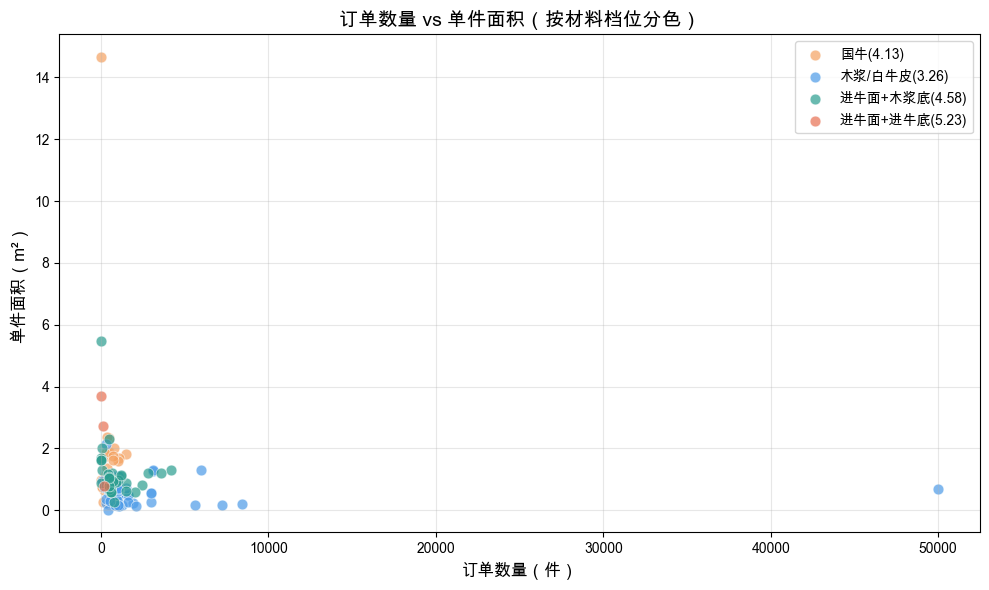

In [30]:
import matplotlib.pyplot as plt
import matplotlib

# 解决中文显示问题
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'
matplotlib.rcParams['axes.unicode_minus'] = False

# 只用有明确档位的数据
df_plot = df_clean[df_clean['材料档位'] != '需询价'].copy()

# 颜色对应每个档位
color_map = {
    '木浆/白牛皮(3.26)':  '#4C9BE8',
    '国牛(4.13)':        '#F4A261',
    '进牛面+木浆底(4.58)': '#2A9D8F',
    '进牛面+进牛底(5.23)': '#E76F51',
}

fig, ax = plt.subplots(figsize=(10, 6))

for label, group in df_plot.groupby('材料档位'):
    ax.scatter(group['排产数量'], group['单件面积'],
               label=label,
               color=color_map[label],
               alpha=0.7, s=60, edgecolors='white', linewidths=0.5)

ax.set_xlabel('订单数量（件）', fontsize=12)
ax.set_ylabel('单件面积（m²）', fontsize=12)
ax.set_title('订单数量 vs 单件面积（按材料档位分色）', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

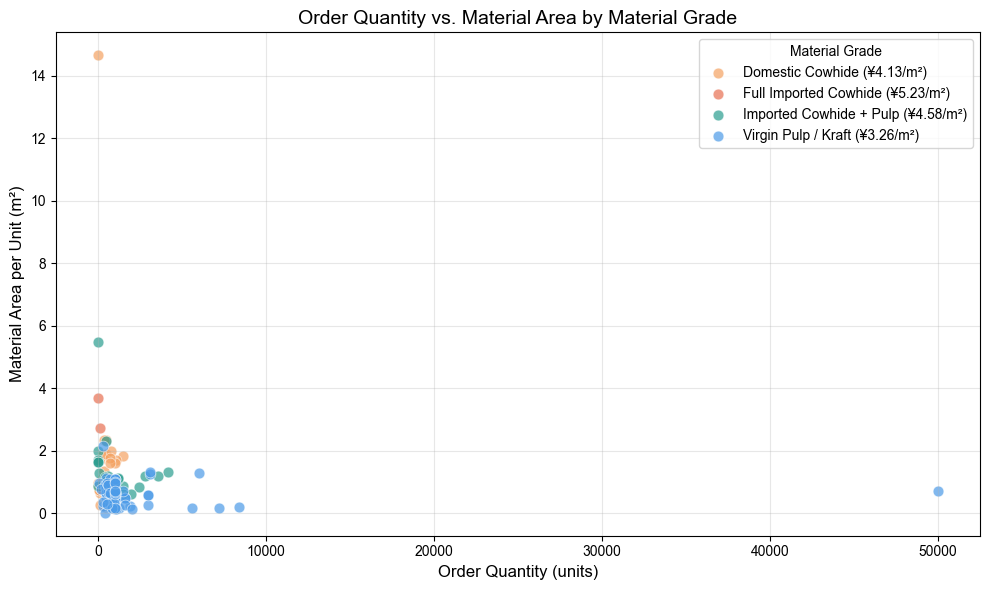

In [31]:
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['axes.unicode_minus'] = False

# 只用有明确档位的数据
df_plot = df_clean[df_clean['材料档位'] != '需询价'].copy()

# 改成英文标签
label_map = {
    '木浆/白牛皮(3.26)':   'Virgin Pulp / Kraft (¥3.26/m²)',
    '国牛(4.13)':          'Domestic Cowhide (¥4.13/m²)',
    '进牛面+木浆底(4.58)':  'Imported Cowhide + Pulp (¥4.58/m²)',
    '进牛面+进牛底(5.23)':  'Full Imported Cowhide (¥5.23/m²)',
}
df_plot['Material Grade'] = df_plot['材料档位'].map(label_map)

color_map = {
    'Virgin Pulp / Kraft (¥3.26/m²)':        '#4C9BE8',
    'Domestic Cowhide (¥4.13/m²)':           '#F4A261',
    'Imported Cowhide + Pulp (¥4.58/m²)':    '#2A9D8F',
    'Full Imported Cowhide (¥5.23/m²)':      '#E76F51',
}

fig, ax = plt.subplots(figsize=(10, 6))

for label, group in df_plot.groupby('Material Grade'):
    ax.scatter(group['排产数量'], group['单件面积'],
               label=label,
               color=color_map[label],
               alpha=0.7, s=60, edgecolors='white', linewidths=0.5)

ax.set_xlabel('Order Quantity (units)', fontsize=12)
ax.set_ylabel('Material Area per Unit (m²)', fontsize=12)
ax.set_title('Order Quantity vs. Material Area by Material Grade', fontsize=14)
ax.legend(fontsize=10, title='Material Grade')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# 先查一下这两个outlier是谁
print('数量最大的3条:')
print(df_plot.nlargest(3, '排产数量')[['订单号','客户名称','排产数量','单件面积','材料档位']])

print()
print('单件面积最大的3条:')
print(df_plot.nlargest(3, '单件面积')[['订单号','客户名称','排产数量','单件面积','材料档位']])

数量最大的3条:
                 订单号            客户名称   排产数量      单件面积          材料档位
44   XS2025091200014  铂斯方得(西安)电子有限公司  50000  0.700000  木浆/白牛皮(3.26)
54   XS2025090600004              白鹿   8400  0.208229  木浆/白牛皮(3.26)
100  XS2025091000006      西安正大制药有限公司   7200  0.173571  木浆/白牛皮(3.26)

单件面积最大的3条:
                 订单号  客户名称  排产数量       单件面积           材料档位
203  XS2025101700020  奇芯光电    10  14.657000       国牛(4.13)
75   XS2025070200005    奉航    11   5.479091  进牛面+木浆底(4.58)
33   XS2025091200002  中航创世    20   3.696500  进牛面+进牛底(5.23)


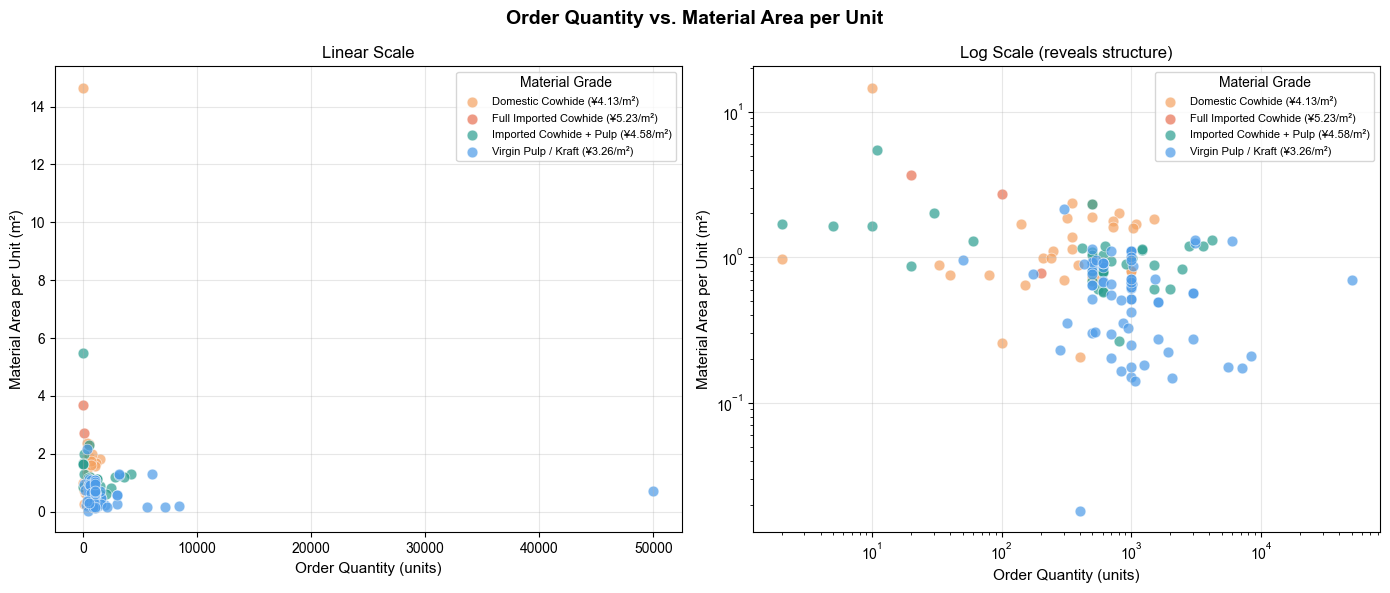

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

color_map = {
    'Virgin Pulp / Kraft (¥3.26/m²)':      '#4C9BE8',
    'Domestic Cowhide (¥4.13/m²)':         '#F4A261',
    'Imported Cowhide + Pulp (¥4.58/m²)':  '#2A9D8F',
    'Full Imported Cowhide (¥5.23/m²)':    '#E76F51',
}

for ax in axes:
    for label, group in df_plot.groupby('Material Grade'):
        ax.scatter(group['排产数量'], group['单件面积'],
                   label=label, color=color_map[label],
                   alpha=0.7, s=60, edgecolors='white', linewidths=0.5)
    ax.set_xlabel('Order Quantity (units)', fontsize=11)
    ax.set_ylabel('Material Area per Unit (m²)', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, title='Material Grade')

# 左图：正常坐标轴
axes[0].set_title('Linear Scale', fontsize=12)

# 右图：对数坐标轴（两个轴都log）
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title('Log Scale (reveals structure)', fontsize=12)

fig.suptitle('Order Quantity vs. Material Area per Unit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('order_quantity_vs_area.png', dpi=300, bbox_inches='tight')
plt.show()

In [34]:
# 纸板单价对照表
price_map = {
    '木浆/白牛皮(3.26)':   3.26,
    '国牛(4.13)':          4.13,
    '进牛面+木浆底(4.58)':  4.58,
    '进牛面+进牛底(5.23)':  5.23,
}

# 加入纸板单价列
df_clean['纸板单价'] = df_clean['材料档位'].map(price_map)

# 算材料成本/件
df_clean['材料成本/件'] = df_clean['单件面积'] * df_clean['纸板单价']

# 只看有明确档位的
df_costed = df_clean[df_clean['纸板单价'].notna()].copy()

print(f'有成本数据的订单: {len(df_costed)} 条')
print()
print('材料成本/件 基本统计:')
print(df_costed['材料成本/件'].describe().round(2))

有成本数据的订单: 151 条

材料成本/件 基本统计:
count    151.00
mean       4.08
std        5.60
min        0.06
25%        2.06
50%        3.00
75%        4.25
max       60.53
Name: 材料成本/件, dtype: float64


/var/folders/vj/6p14yjb10mq_8rcpl7b3sng00000gn/T/ipykernel_76254/56292817.py:37: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_by_grade, patch_artist=True, labels=labels_by_grade)


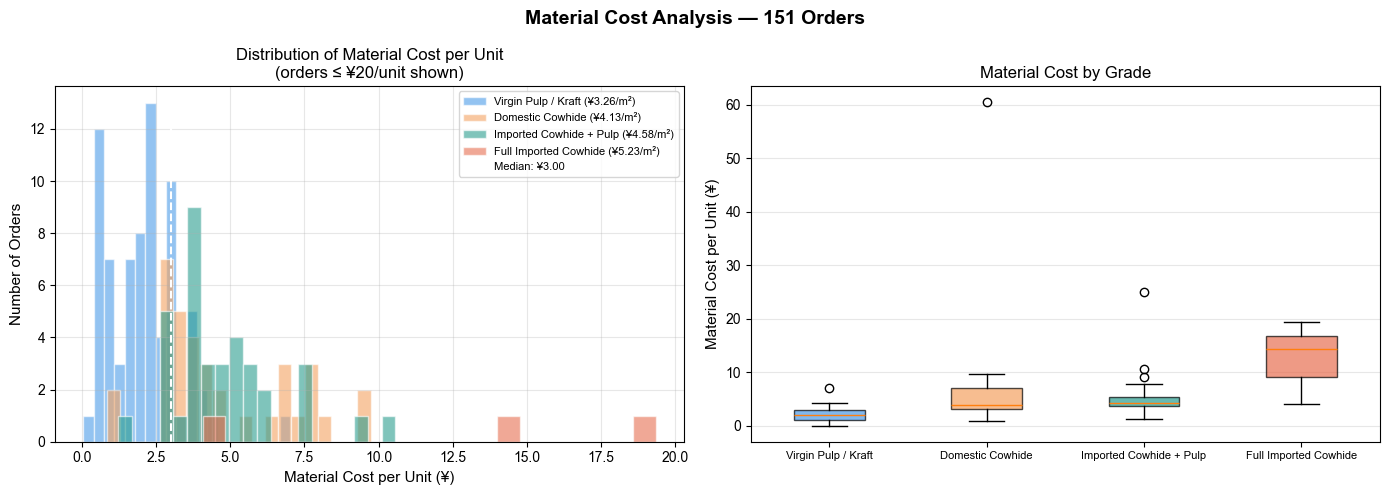

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_map_en = {
    '木浆/白牛皮(3.26)':   ('Virgin Pulp / Kraft (¥3.26/m²)',     '#4C9BE8'),
    '国牛(4.13)':          ('Domestic Cowhide (¥4.13/m²)',         '#F4A261'),
    '进牛面+木浆底(4.58)':  ('Imported Cowhide + Pulp (¥4.58/m²)', '#2A9D8F'),
    '进牛面+进牛底(5.23)':  ('Full Imported Cowhide (¥5.23/m²)',   '#E76F51'),
}

# 左图：材料成本分布直方图（去掉最大的outlier让图好看）
df_hist = df_costed[df_costed['材料成本/件'] <= 20]
for grade, (eng_label, color) in color_map_en.items():
    subset = df_hist[df_hist['材料档位'] == grade]['材料成本/件']
    if len(subset) > 0:
        axes[0].hist(subset, bins=20, label=eng_label,
                     color=color, alpha=0.6, edgecolor='white')

axes[0].axvline(df_costed['材料成本/件'].median(), color='white',
                linestyle='--', linewidth=1.5, label=f'Median: ¥{df_costed["材料成本/件"].median():.2f}')
axes[0].set_xlabel('Material Cost per Unit (¥)', fontsize=11)
axes[0].set_ylabel('Number of Orders', fontsize=11)
axes[0].set_title('Distribution of Material Cost per Unit\n(orders ≤ ¥20/unit shown)', fontsize=12)
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 右图：各材料档位的成本箱线图
data_by_grade = []
labels_by_grade = []
colors_by_grade = []
for grade, (eng_label, color) in color_map_en.items():
    subset = df_costed[df_costed['材料档位'] == grade]['材料成本/件']
    if len(subset) > 0:
        data_by_grade.append(subset.values)
        labels_by_grade.append(eng_label.split(' (')[0])  # 短标签
        colors_by_grade.append(color)

bp = axes[1].boxplot(data_by_grade, patch_artist=True, labels=labels_by_grade)
for patch, color in zip(bp['boxes'], colors_by_grade):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_ylabel('Material Cost per Unit (¥)', fontsize=11)
axes[1].set_title('Material Cost by Grade', fontsize=12)
axes[1].tick_params(axis='x', labelsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

fig.suptitle('Material Cost Analysis — 151 Orders', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('material_cost_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

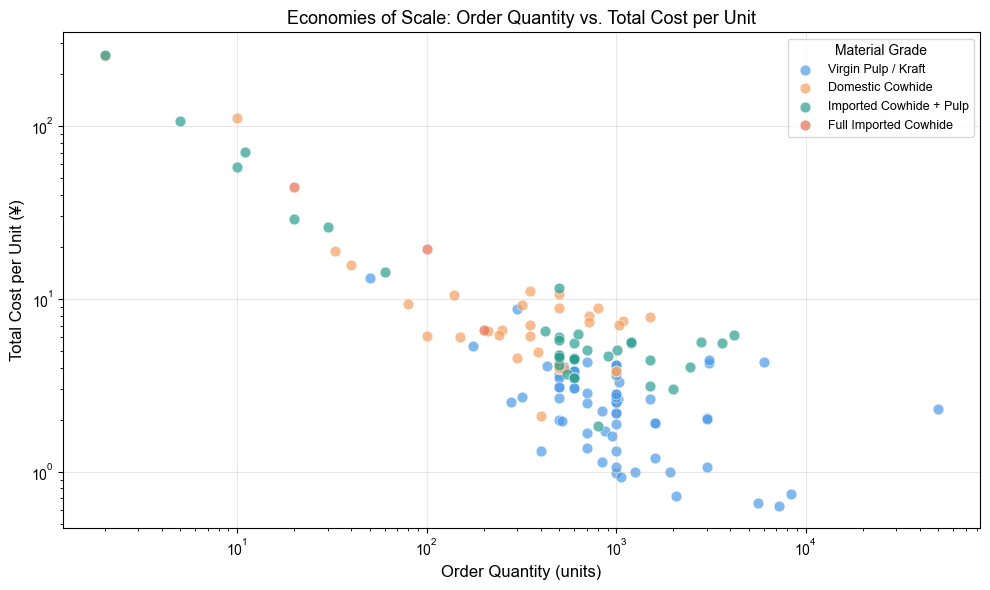

In [36]:
# 算单件运费摊销（假设每趟运费500元）
DELIVERY_COST = 500  # 元/趟，可调整

df_costed['运费摊销/件'] = DELIVERY_COST / df_costed['排产数量']
df_costed['单件总成本']  = df_costed['材料成本/件'] + df_costed['运费摊销/件']

# 画图：订单数量 vs 单件总成本
fig, ax = plt.subplots(figsize=(10, 6))

for grade, (eng_label, color) in color_map_en.items():
    subset = df_costed[df_costed['材料档位'] == grade]
    if len(subset) > 0:
        ax.scatter(subset['排产数量'], subset['单件总成本'],
                   label=eng_label.split(' (')[0],
                   color=color, alpha=0.7, s=60,
                   edgecolors='white', linewidths=0.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Order Quantity (units)', fontsize=12)
ax.set_ylabel('Total Cost per Unit (¥)', fontsize=12)
ax.set_title('Economies of Scale: Order Quantity vs. Total Cost per Unit', fontsize=13)
ax.legend(fontsize=9, title='Material Grade')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [38]:
import subprocess
import sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'scipy'])

Could not fetch URL https://pypi.org/simple/pip/: There was a problem confirming the ssl certificate: HTTPSConnectionPool(host='pypi.org', port=443): Max retries exceeded with url: /simple/pip/ (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)'))) - skipping


CompletedProcess(args=['/Users/baitao/PyCharmMiscProject/.venv1/bin/python', '-m', 'pip', 'install', 'scipy'], returncode=0)

In [39]:
from scipy import stats

# 取log（因为在log坐标下是直线，所以用线性回归拟合log值）
df_fit = df_costed[df_costed['单件总成本'] > 0].copy()

log_q    = np.log(df_fit['排产数量'])
log_cost = np.log(df_fit['单件总成本'])

# 线性回归：log(cost) = log(a) + b * log(quantity)
slope, intercept, r_value, p_value, std_err = stats.linregress(log_q, log_cost)

a = np.exp(intercept)
b = slope

print(f'拟合结果:')
print(f'  a = {a:.4f}')
print(f'  b = {b:.4f}')
print(f'  R² = {r_value**2:.4f}')
print(f'  p值 = {p_value:.4e}')
print()
print(f'公式: 单件总成本 = {a:.2f} × 数量^({b:.3f})')

拟合结果:
  a = 155.3968
  b = -0.5666
  R² = 0.6656
  p值 = 2.8998e-37

公式: 单件总成本 = 155.40 × 数量^(-0.567)


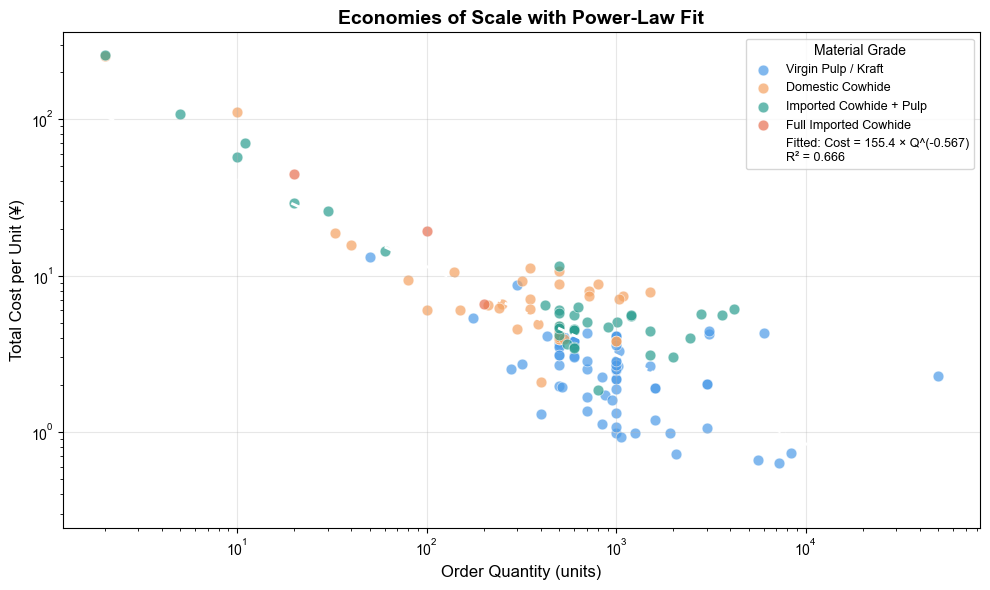

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))

# 画散点
for grade, (eng_label, color) in color_map_en.items():
    subset = df_costed[df_costed['材料档位'] == grade]
    if len(subset) > 0:
        ax.scatter(subset['排产数量'], subset['单件总成本'],
                   label=eng_label.split(' (')[0],
                   color=color, alpha=0.7, s=60,
                   edgecolors='white', linewidths=0.5)

# 画拟合曲线
q_range = np.linspace(df_costed['排产数量'].min(),
                       df_costed['排产数量'].max(), 300)
cost_fitted = a * q_range ** b

ax.plot(q_range, cost_fitted, color='white', linewidth=2,
        linestyle='--', label=f'Fitted: Cost = {a:.1f} × Q^({b:.3f})\nR² = {r_value**2:.3f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Order Quantity (units)', fontsize=12)
ax.set_ylabel('Total Cost per Unit (¥)', fontsize=12)
ax.set_title('Economies of Scale with Power-Law Fit', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, title='Material Grade')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

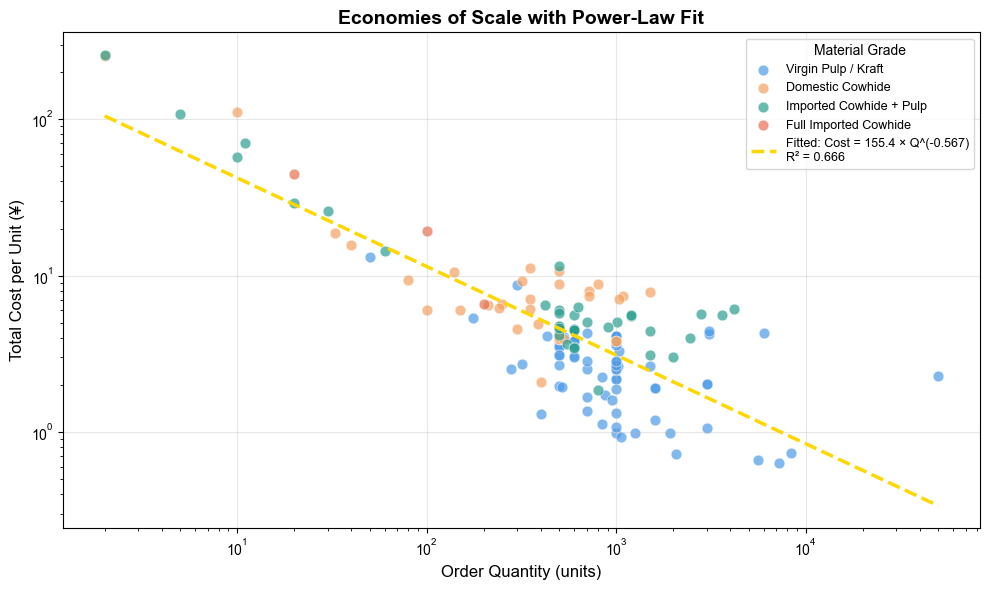

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

# 画散点
for grade, (eng_label, color) in color_map_en.items():
    subset = df_costed[df_costed['材料档位'] == grade]
    if len(subset) > 0:
        ax.scatter(subset['排产数量'], subset['单件总成本'],
                   label=eng_label.split(' (')[0],
                   color=color, alpha=0.7, s=60,
                   edgecolors='white', linewidths=0.5)

# 在log空间里生成x点，这样曲线才均匀分布
q_range = np.logspace(np.log10(df_costed['排产数量'].min()),
                       np.log10(df_costed['排产数量'].max()), 300)
cost_fitted = a * q_range ** b

ax.plot(q_range, cost_fitted, color='#FFD700', linewidth=2.5,
        linestyle='--',
        label=f'Fitted: Cost = {a:.1f} × Q^({b:.3f})\nR² = {r_value**2:.3f}')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Order Quantity (units)', fontsize=12)
ax.set_ylabel('Total Cost per Unit (¥)', fontsize=12)
ax.set_title('Economies of Scale with Power-Law Fit', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, title='Material Grade')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('economies_of_scale_fit.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# 算运费摊销占总成本的比例
df_costed['运费占比'] = df_costed['运费摊销/件'] / df_costed['单件总成本']

# 按数量分成五个区间
bins   = [0, 50, 200, 500, 2000, float('inf')]
labels = ['<50', '50-200', '200-500', '500-2000', '>2000']

df_costed['数量区间'] = pd.cut(df_costed['排产数量'], bins=bins, labels=labels)

# 每个区间的成本结构统计
summary = df_costed.groupby('数量区间', observed=True).agg(
    订单数      = ('排产数量', 'count'),
    平均数量    = ('排产数量', 'mean'),
    平均材料成本 = ('材料成本/件', 'mean'),
    平均运费摊销 = ('运费摊销/件', 'mean'),
    平均总成本  = ('单件总成本', 'mean'),
    运费占比    = ('运费占比', 'mean'),
).round(3)

print(summary)

          订单数      平均数量  平均材料成本  平均运费摊销   平均总成本   运费占比
数量区间                                                  
<50        12    19.417  12.906  70.814  83.720  0.774
50-200      8   125.625   5.085   4.606   9.690  0.518
200-500    41   434.317   3.934   1.223   5.157  0.289
500-2000   75   932.600   2.883   0.598   3.481  0.215
>2000      15  7167.333   2.837   0.134   2.972  0.080


In [43]:
# 根据运费占比推导建议加成率
# 逻辑：运费占比越高，加成率越高
# 我们设定：基础加成率12%，每增加10%的运费占比，多加3%

def suggested_margin(delivery_ratio):
    base = 0.12
    extra = (delivery_ratio / 0.10) * 0.03
    return round(min(base + extra, 0.50), 2)  # 最高封顶50%

summary['建议加成率'] = summary['运费占比'].apply(suggested_margin)
summary['建议单价'] = (summary['平均总成本'] * (1 + summary['建议加成率'])).round(3)
summary['vs 固定20%单价'] = (summary['平均总成本'] * 1.20).round(3)

print(summary[['订单数', '平均总成本', '运费占比', '建议加成率', '建议单价', 'vs 固定20%单价']])

          订单数   平均总成本   运费占比  建议加成率     建议单价  vs 固定20%单价
数量区间                                                    
<50        12  83.720  0.774   0.35  113.022     100.464
50-200      8   9.690  0.518   0.28   12.403      11.628
200-500    41   5.157  0.289   0.21    6.240       6.188
500-2000   75   3.481  0.215   0.18    4.108       4.177
>2000      15   2.972  0.080   0.14    3.388       3.566


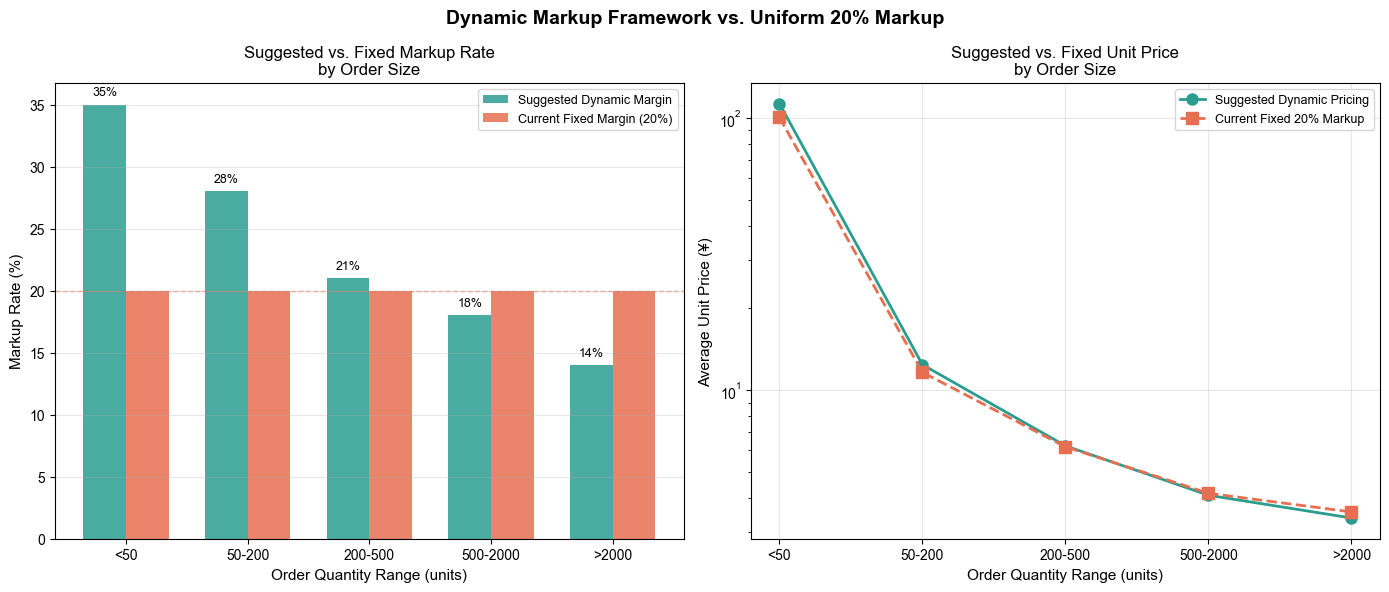

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

intervals = ['<50', '50-200', '200-500', '500-2000', '>2000']
x = np.arange(len(intervals))
width = 0.35

# 左图：建议加成率 vs 固定20%
margins_suggested = summary['建议加成率'].values * 100
margins_fixed     = [20] * len(intervals)

bars1 = axes[0].bar(x - width/2, margins_suggested, width,
                     label='Suggested Dynamic Margin', color='#2A9D8F', alpha=0.85)
bars2 = axes[0].bar(x + width/2, margins_fixed, width,
                     label='Current Fixed Margin (20%)', color='#E76F51', alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(intervals, fontsize=10)
axes[0].set_xlabel('Order Quantity Range (units)', fontsize=11)
axes[0].set_ylabel('Markup Rate (%)', fontsize=11)
axes[0].set_title('Suggested vs. Fixed Markup Rate\nby Order Size', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(20, color='#E76F51', linestyle='--', linewidth=1, alpha=0.5)

# 在bar上标数字
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=9)

# 右图：建议单价 vs 固定20%单价
price_suggested = summary['建议单价'].values
price_fixed     = summary['vs 固定20%单价'].values

axes[1].plot(intervals, price_suggested, 'o-', color='#2A9D8F',
             linewidth=2, markersize=8, label='Suggested Dynamic Pricing')
axes[1].plot(intervals, price_fixed, 's--', color='#E76F51',
             linewidth=2, markersize=8, label='Current Fixed 20% Markup')

axes[1].set_xlabel('Order Quantity Range (units)', fontsize=11)
axes[1].set_ylabel('Average Unit Price (¥)', fontsize=11)
axes[1].set_title('Suggested vs. Fixed Unit Price\nby Order Size', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

fig.suptitle('Dynamic Markup Framework vs. Uniform 20% Markup',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dynamic_markup_framework.png', dpi=300, bbox_inches='tight')
plt.show()